## Introduction

For this project, we have data pertaining to information about an online store that sells several goods. The data includes invoice numbers, stock codes, description of items, quantity of items, dates, unit price, and customer ids. Throughout this project, we will explore the product range, analyze date trends, item trends, and conduct statistical analysis to determine any insights.

## Data Preprocessing

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy import stats
from datetime import datetime as dt
import warnings
warnings.filterwarnings("ignore")

<div class="alert alert-block alert-success">
<b> Team Lead Comment </b> <br>
HiThank you so much for your work! I truly enjoed it :) Especially the categorization and testing parts.
    There were some misunderstanding, I guess, in the aggregations with quantity/stockcode, but it's minor thing. Congrats on passing the Final project! 
 <a class="tocSkip"></a>
</div>

In [48]:
try:
    df = pd.read_csv('ecommerce_dataset_us.csv', '\t')
except:
    df = pd.read_csv('/datasets/ecommerce_dataset_us.csv', '\t')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,11/29/2018 08:26,2.55,17850.0
1,536365,71053,WHITE METAL LANTERN,6,11/29/2018 08:26,3.39,17850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,11/29/2018 08:26,2.75,17850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,11/29/2018 08:26,3.39,17850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,11/29/2018 08:26,3.39,17850.0


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 28.9+ MB


In [50]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [51]:
# lowercase
df.columns = df.columns.str.lower()
df.columns

Index(['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate',
       'unitprice', 'customerid'],
      dtype='object')

In [52]:
# datetime
df.invoicedate = pd.to_datetime(df.invoicedate)
df.invoicedate.head()

0   2018-11-29 08:26:00
1   2018-11-29 08:26:00
2   2018-11-29 08:26:00
3   2018-11-29 08:26:00
4   2018-11-29 08:26:00
Name: invoicedate, dtype: datetime64[ns]

In [53]:
# adding date columns
df['date'] = df['invoicedate'].dt.date
df['date'] = df['date'].astype('datetime64')
df['month'] = df['date'].astype('datetime64[M]')

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    541909 non-null  object        
 1   stockcode    541909 non-null  object        
 2   description  540455 non-null  object        
 3   quantity     541909 non-null  int64         
 4   invoicedate  541909 non-null  datetime64[ns]
 5   unitprice    541909 non-null  float64       
 6   customerid   406829 non-null  float64       
 7   date         541909 non-null  datetime64[ns]
 8   month        541909 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(1), object(3)
memory usage: 37.2+ MB


### Missing Values

In [55]:
df.isna().sum()

invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
date                0
month               0
dtype: int64

In [56]:
# Percentages
df.isna().sum()/len(df) * 100

invoiceno       0.000000
stockcode       0.000000
description     0.268311
quantity        0.000000
invoicedate     0.000000
unitprice       0.000000
customerid     24.926694
date            0.000000
month           0.000000
dtype: float64

In [57]:
df[df.description.isna()].sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,date,month
193997,553548,75131,NaN,-48,2019-05-15 15:57:00,0.0,NaN,2019-05-15,2019-05-01
140196,548377,85016,NaN,-46,2019-03-28 16:40:00,0.0,NaN,2019-03-28,2019-03-01
14062,537451,84881,NaN,-11,2018-12-05 09:27:00,0.0,NaN,2018-12-05,2018-12-01
218699,556061,20906,NaN,-21,2019-06-06 14:04:00,0.0,NaN,2019-06-06,2019-06-01
166511,550929,22470,NaN,2,2019-04-19 14:41:00,0.0,NaN,2019-04-19,2019-04-01
250532,559037,82583,NaN,10,2019-07-03 15:29:00,0.0,NaN,2019-07-03,2019-07-01
78457,542883,21448,NaN,-40,2019-01-30 13:07:00,0.0,NaN,2019-01-30,2019-01-01
136272,547957,20713,NaN,32,2019-03-26 15:16:00,0.0,NaN,2019-03-26,2019-03-01
142008,548540,90035A,NaN,-9,2019-03-29 17:51:00,0.0,NaN,2019-03-29,2019-03-01
280660,561483,77079,NaN,4,2019-07-25 13:40:00,0.0,NaN,2019-07-25,2019-07-01


Since the items with description represent a small small proportion, it is safe to remove these items to avoid complications later on.

In [58]:
df = df[~df.description.isna()]
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 540455 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    540455 non-null  object        
 1   stockcode    540455 non-null  object        
 2   description  540455 non-null  object        
 3   quantity     540455 non-null  int64         
 4   invoicedate  540455 non-null  datetime64[ns]
 5   unitprice    540455 non-null  float64       
 6   customerid   406829 non-null  float64       
 7   date         540455 non-null  datetime64[ns]
 8   month        540455 non-null  datetime64[ns]
dtypes: datetime64[ns](3), float64(2), int64(1), object(3)
memory usage: 41.2+ MB


In [59]:
df[df.customerid.isna()].sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,date,month
16097,537643,84884a,ANT WHITE WIRE HEART SPIRAL,1,2018-12-05 15:34:00,8.47,NaN,2018-12-05,2018-12-01
450627,575176,23568,EGG CUP HENRIETTA HEN CREAM,1,2019-11-06 18:29:00,2.46,NaN,2019-11-06,2019-11-01
60510,541422,21027,NINJA RABBIT PINK,1,2019-01-15 17:48:00,0.83,NaN,2019-01-15,2019-01-01
416592,572553,22694,WICKER STAR,1,2019-10-22 17:09:00,4.13,NaN,2019-10-22,2019-10-01
470054,576617,22371,AIRLINE BAG VINTAGE TOKYO 78,1,2019-11-13 16:57:00,8.29,NaN,2019-11-13,2019-11-01
496887,578347,22905,CALENDAR IN SEASON DESIGN,4,2019-11-22 09:26:00,2.46,NaN,2019-11-22,2019-11-01
268567,560433,22721,SET OF 3 CAKE TINS SKETCHBOOK,4,2019-07-16 15:49:00,4.13,NaN,2019-07-16,2019-07-01
67148,541827,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,2,2019-01-19 17:05:00,4.13,NaN,2019-01-19,2019-01-01
389133,570465,22464,HANGING METAL HEART LANTERN,1,2019-10-08 16:02:00,3.29,NaN,2019-10-08,2019-10-01
529867,580754,23301,GARDENERS KNEELING PAD KEEP CALM,1,2019-12-04 10:05:00,4.13,NaN,2019-12-04,2019-12-01


customerid missing values represent a larger proportion, and there is no defining characteristic for the missing values. Unlike the missing values in description, all other metrics appear to be useful for analysis. Therefore, we will leave these values in. 

### Duplicate Values

In [60]:
df.duplicated().sum()

5268

In [61]:
df.duplicated().sum()/len(df) * 100

0.9747342516953308

In [62]:
df = df.drop_duplicates()
df.duplicated().sum()

0

Since the percentage of duplicates is only .97% of all values, it is safe to drop all duplicates.

<div class="alert alert-block alert-success">
<b> Team Lead Comment </b> <br>
+
 <a class="tocSkip"></a>
</div>

## EDA

In [63]:
df.describe()

,quantity,unitprice,customerid
count,535187.000000,535187.000000,401604.000000
mean,9.671593,4.645242,15281.160818
std,219.059056,97.364810,1714.006089
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13939.000000
50%,3.000000,2.080000,15145.000000
75%,10.000000,4.130000,16784.000000
max,80995.000000,38970.000000,18287.000000


In [64]:
df.query('unitprice < 0')

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,date,month
299983,A563186,B,Adjust bad debt,1,2019-08-10 14:51:00,-11062.06,NaN,2019-08-10,2019-08-01
299984,A563187,B,Adjust bad debt,1,2019-08-10 14:52:00,-11062.06,NaN,2019-08-10,2019-08-01


In [65]:
# removing the two anomolous rows
df = df.query('unitprice >= 0')

In [66]:
df.quantity.describe()

count    535185.000000
mean          9.671626
std         219.059465
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: quantity, dtype: float64

In [67]:
df.query('quantity < 0').sample(10)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,date,month
404832,C571695,22522,CHILDS GARDEN FORK BLUE,-12,2019-10-16 14:46:00,0.85,14776.0,2019-10-16,2019-10-01
133914,C547806,21232,STRAWBERRY CERAMIC TRINKET BOX,-1,2019-03-23 13:37:00,1.25,12528.0,2019-03-23,2019-03-01
465413,C576229,23236,STORAGE TIN VINTAGE DOILY,-3,2019-11-12 13:13:00,2.89,13816.0,2019-11-12,2019-11-01
466259,C576324,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,-6,2019-11-12 15:10:00,1.25,16161.0,2019-11-12,2019-11-01
88070,C543757,22068,BLACK PIRATE TREASURE CHEST,-1,2019-02-09 15:05:00,1.65,13115.0,2019-02-09,2019-02-01
181042,552443,22796,Not rcvd in 10/11/2010 delivery,-360,2019-05-07 13:05:00,0.00,NaN,2019-05-07,2019-05-01
168326,C551018,22328,ROUND SNACK BOXES SET OF 4 FRUITS,-1,2019-04-24 11:19:00,2.95,12705.0,2019-04-24,2019-04-01
319945,C564948,21784,SHOE SHINE BOX,-2,2019-08-29 13:29:00,9.95,14895.0,2019-08-29,2019-08-01
268316,C560409,82482,WOODEN PICTURE FRAME WHITE FINISH,-6,2019-07-16 14:24:00,2.55,16717.0,2019-07-16,2019-07-01
234375,C557512,21390,FILIGRIS HEART WITH BUTTERFLY,-3,2019-06-18 16:52:00,1.25,15700.0,2019-06-18,2019-06-01


Negative/returned quantites represent a considerable size, and further analysis can be useful.

In [68]:
def distribution_plots(parameter):
    print('The histogram and boxplots of: {}'.format(parameter))

    df[parameter].hist()
    plt.show()
    df.boxplot(column = parameter)
    plt.show()
    if df[parameter].mean()>df[parameter].median():
        print('The distribution is skewed to the right')
    else:
        print('The distribution is skewed to the left')
    # Percentile Technique
    print('---------------------------------------')
    print('Percentile Technique:')
    print('---------------------------------------')
    print('Statistics on: {}'.format(parameter))
    print(df[parameter].describe())
    ninety_five = np.percentile(df[parameter], 95).round()
    five = np.percentile(df[parameter], 5).round()
    print('---------------------------------------')
    print('min border:',five)
    print('max border:',ninety_five)
    print('---------------------------------------')
    print('The outliers are considered to be values below', five, "and above",ninety_five)
    print('We have',len(df[(df[parameter]<five)|(df[parameter]>ninety_five)]),"values that we can consider outliers")
    # IQR Technique
    print('\nIQR Technique:')
    print('---------------------------------------')
    print('Statistics on: {}'.format(parameter))
    print(df[parameter].describe())
    Q1 = df[parameter].quantile(0.25)
    Q3 = df[parameter].quantile(0.75)
    IQR = Q3 - Q1
    min_iqr=Q1-1.5*IQR
    max_iqr=Q3+1.5*IQR
    print('---------------------------------------')
    print('min border:',min_iqr)
    print('max border:',max_iqr)
    print('---------------------------------------')
    #if min_iqr<0:
        #print('The outliers are considered to be values above',max_iqr)
        #print('We have',len(df[df[parameter]>max_iqr]),"values that we can consider outliers")
    #else:
    print('The outliers are considered to be values below',min_iqr.round(2), "and above",max_iqr)
    print('We have',len(df[(df[parameter]<min_iqr)|(df[parameter]>max_iqr)]),"values that we can consider outliers")

The histogram and boxplots of: unitprice


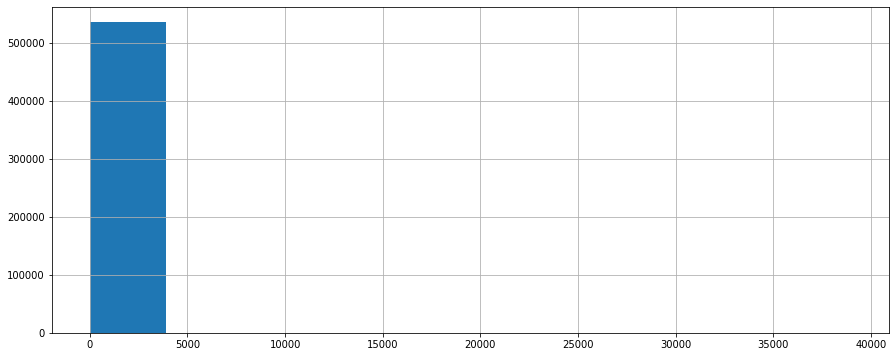

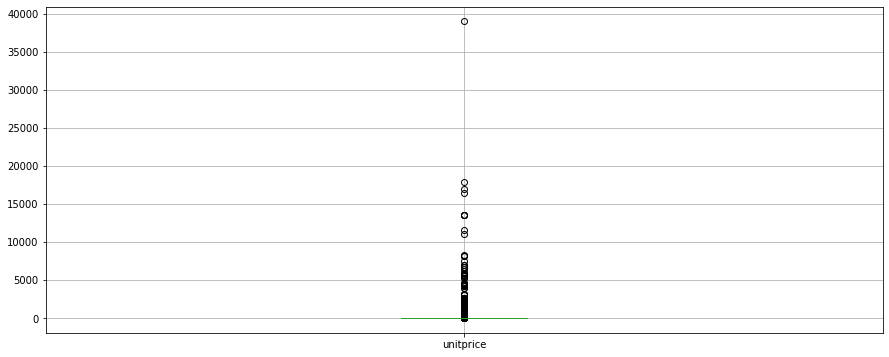

The distribution is skewed to the right
---------------------------------------
Percentile Technique:
---------------------------------------
Statistics on: unitprice
count    535185.000000
mean          4.686598
std          94.985568
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: unitprice, dtype: float64
---------------------------------------
min border: 0.0
max border: 10.0
---------------------------------------
The outliers are considered to be values below 0.0 and above 10.0
We have 24954 values that we can consider outliers

IQR Technique:
---------------------------------------
Statistics on: unitprice
count    535185.000000
mean          4.686598
std          94.985568
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: unitprice, dtype: float64
---------------------------------------
min border: -3.0700000000000003
max border: 8.45
-

In [69]:
distribution_plots('unitprice')

The histogram and boxplots of: quantity


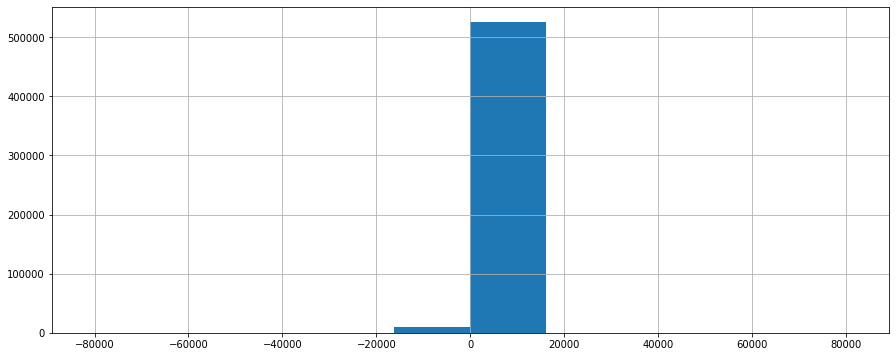

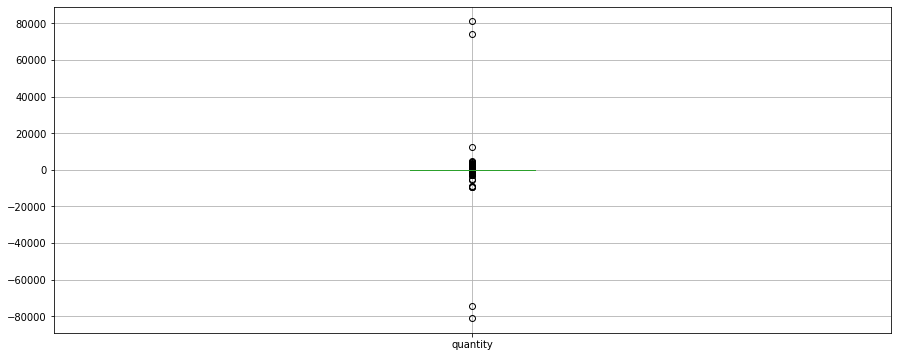

The distribution is skewed to the right
---------------------------------------
Percentile Technique:
---------------------------------------
Statistics on: quantity
count    535185.000000
mean          9.671626
std         219.059465
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: quantity, dtype: float64
---------------------------------------
min border: 1.0
max border: 30.0
---------------------------------------
The outliers are considered to be values below 1.0 and above 30.0
We have 35421 values that we can consider outliers

IQR Technique:
---------------------------------------
Statistics on: quantity
count    535185.000000
mean          9.671626
std         219.059465
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: quantity, dtype: float64
---------------------------------------
min border: -12.5
max border: 23.5
-------------------

In [70]:
distribution_plots('quantity')

We will remove outliers from the IQR technique for further analysis.

In [71]:
df = df.query('unitprice <= 8.45')
df = df[df.quantity.between(-12.5, 23.5)]

In [72]:
df.unitprice.describe()

count    438333.000000
mean          2.705536
std           1.931058
min           0.000000
25%           1.250000
50%           2.080000
75%           3.750000
max           8.330000
Name: unitprice, dtype: float64

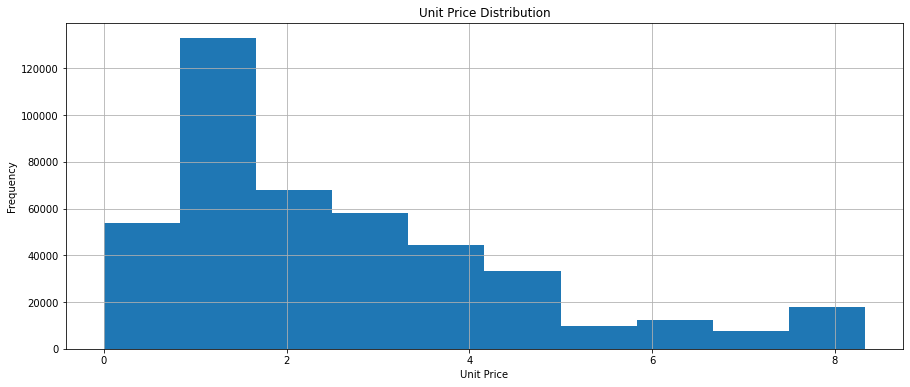

In [73]:
df.unitprice.hist();
plt.title('Unit Price Distribution');
plt.xlabel('Unit Price');
plt.ylabel('Frequency');

The distribution is skewed to the right, meaning that there are fewer high priced items and more lower priced items.

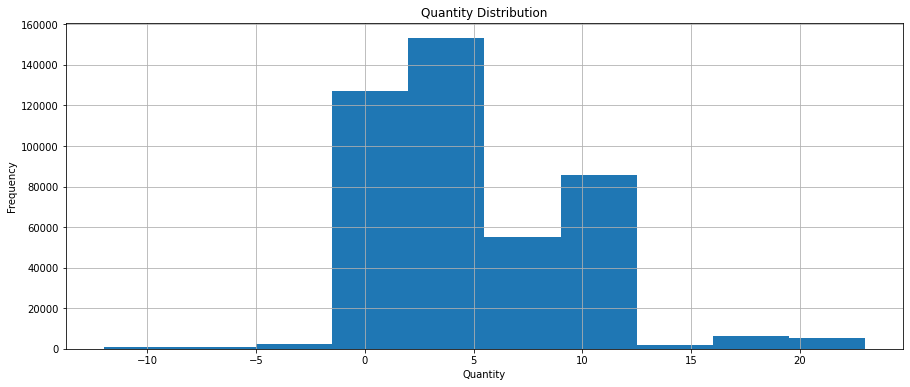

In [74]:
df.quantity.hist();
plt.title('Quantity Distribution');
plt.xlabel('Quantity');
plt.ylabel('Frequency');

Items are more often sold in lower (absolute) quantities, as expected.

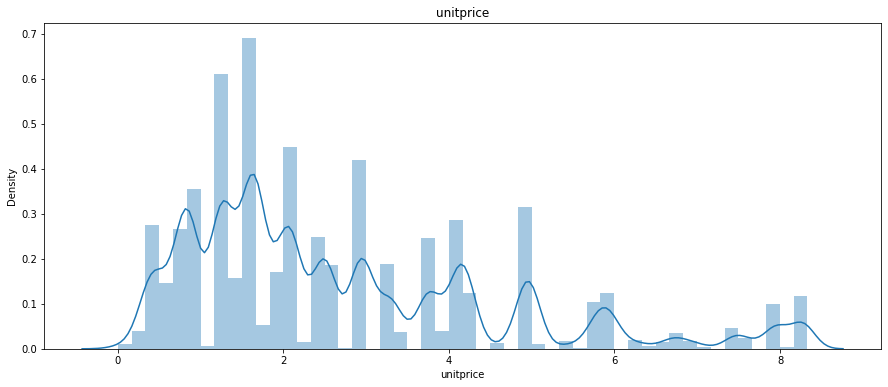

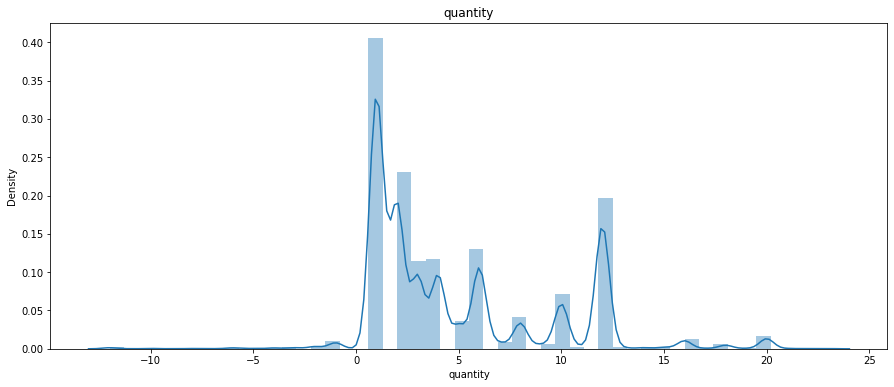

In [75]:
for column in df[['unitprice', 'quantity']]:
    sns.distplot(df[column])
    plt.title(column)
    plt.show()

In [76]:
# Calculating Revenue
df['revenue'] = df.quantity * df.unitprice
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,date,month,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2018-11-29 08:26:00,2.55,17850.0,2018-11-29,2018-11-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2018-11-29 08:26:00,3.39,17850.0,2018-11-29,2018-11-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2018-11-29 08:26:00,2.75,17850.0,2018-11-29,2018-11-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2018-11-29 08:26:00,3.39,17850.0,2018-11-29,2018-11-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2018-11-29 08:26:00,3.39,17850.0,2018-11-29,2018-11-01,20.34


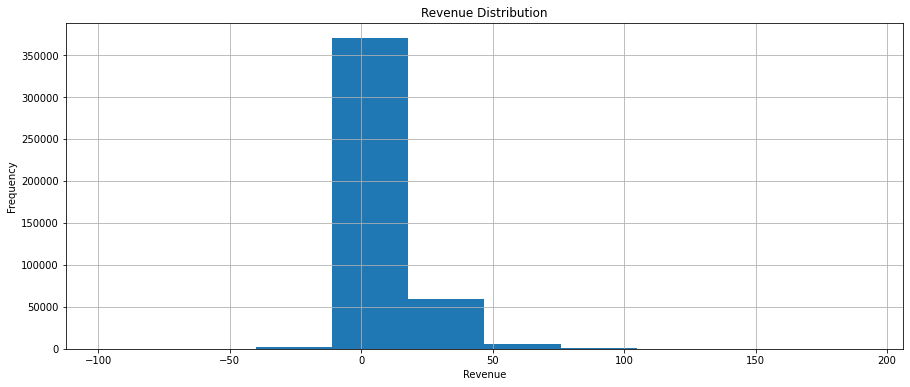

In [77]:
df.revenue.hist();
plt.title('Revenue Distribution');
plt.xlabel('Revenue');
plt.ylabel('Frequency');

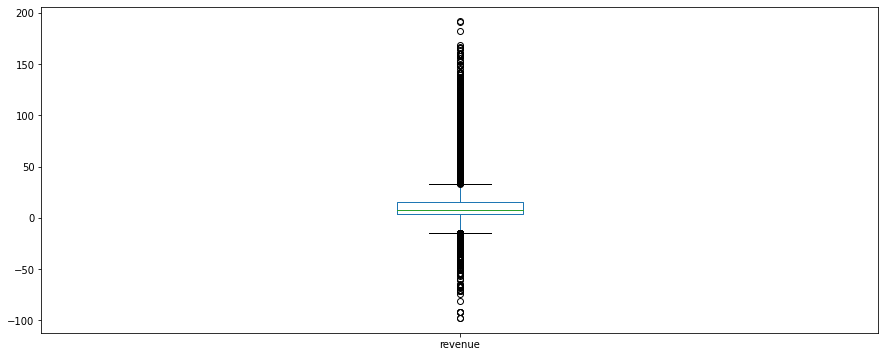

In [78]:
df.revenue.plot(kind = 'box');

The distribution of revenue is slightly skewed to the right.

In [79]:
df.date.describe()

count                  438333
unique                    305
top       2019-12-03 00:00:00
freq                     4409
first     2018-11-29 00:00:00
last      2019-12-07 00:00:00
Name: date, dtype: object

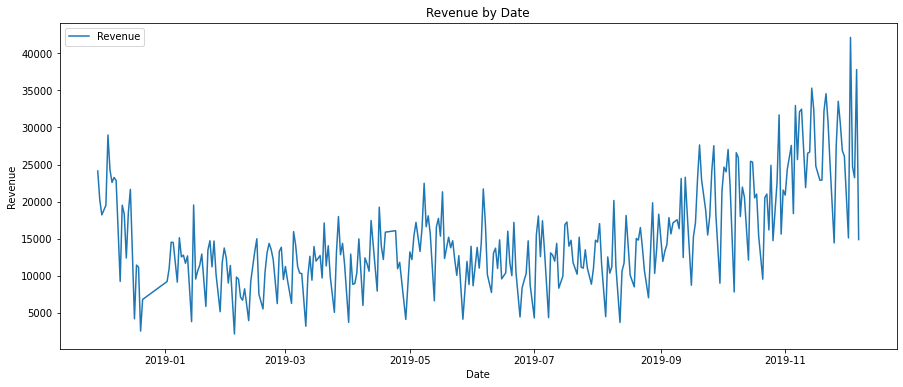

In [80]:
plt.rcParams["figure.figsize"] = (15,6)
plt.plot(df.groupby('date')['revenue'].sum(), label='Revenue')
plt.legend()
plt.title('Revenue by Date')
plt.xlabel('Date')
plt.ylabel('Revenue');

According to the above graph, the highest revenue appears to occur towards the end of the year (note that the start of the graph occurs towards the end of 2018). 

In [81]:
df.groupby('description')['revenue'].sum().sort_values(ascending = False).head().reset_index()

,description,revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,33764.42
1,PARTY BUNTING,33703.01
2,JUMBO BAG RED RETROSPOT,32054.02
3,SPOTTY BUNTING,22515.55
4,JAM MAKING SET WITH JARS,22312.44


In [82]:
fig = px.bar(df.groupby('description')['revenue'].sum().sort_values(ascending = False).reset_index().head(), x = 'description',
             y = 'revenue', title = 'Top 5 Products by Revenue',
            labels={
                     "description": "Description",
                     "revenue": "Revenue"})
fig.show()

In [83]:
df_pos = df.query('quantity > 0')
df_neg = df.query('quantity < 0')

In [84]:
fig = px.bar(df_pos.description.value_counts().reset_index().head(), x = 'index',
             y = 'description', title = 'Top 5 Purchased Products',
            labels={
                     "description": "Number Purchased",
                     "index": "Description"})
fig.show()

<div class="alert alert-block alert-warning">
<b> Team Lead Comment </b> <br>
I'd say here value_counts() just represents the "popularity", nit the real quantity, but ok)
 <a class="tocSkip"></a>
</div>

In [85]:
fig = px.bar(df_neg.description.value_counts().reset_index().head(), x = 'index',
             y = 'description', title = 'Top 5 Returned Products',
            labels={
                     "description": "Number Returned",
                     "index": "Description"})
fig.show()

## Hypothesis Testing

### Proportion Test

Here we will test the hypothesis that the amount of items returned per order(invoice) per customer is less than the amount of items purchased per order per customer. 

Null Hypothesis (H0): The proportion of items returned per order per customer and the proportion of items purchased per order per customer are not significantly different.

Alternative Hypothesis (H1): The proportion of items returned per order per customer and the proportion of items purchased per order per customer are significantly different.

<div class="alert alert-block alert-danger">
<b> Team Lead Comment </b> <br>
I have question regarding proportion. Proportion is the share of something. so when we say, proportion of items returned per order? Do you mean out of all orders? Yes, we can count, for example, what's % of items was returned out of all items bought, but then, again, how would you compare it to the proportion of items purchased per order ?
    What is proportion of items purchased per order per customer ? Like proportion of what?
 <a class="tocSkip"></a>
</div>

In [86]:
orders_unique_pos = df_pos.groupby('customerid')['invoiceno'].nunique().reset_index()
orders_unique_pos.head()

,customerid,invoiceno
0,12347.0,7
1,12348.0,1
2,12349.0,1
3,12350.0,1
4,12352.0,7


In [87]:
orders_unique_neg = df_neg.groupby('customerid')['invoiceno'].nunique().reset_index()
orders_unique_neg.head()

,customerid,invoiceno
0,12352.0,1
1,12359.0,2
2,12362.0,3
3,12375.0,1
4,12379.0,1


In [88]:
orders_count_pos = df_pos.groupby('customerid')['invoiceno'].count().reset_index()
orders_count_pos.head()

,customerid,invoiceno
0,12347.0,141
1,12348.0,1
2,12349.0,61
3,12350.0,15
4,12352.0,67


In [89]:
orders_count_neg = df_neg.groupby('customerid')['invoiceno'].count().reset_index()
orders_count_neg.head()

,customerid,invoiceno
0,12352.0,7
1,12359.0,3
2,12362.0,6
3,12375.0,1
4,12379.0,1


In [93]:
orders_unique_pos

,customerid,invoiceno
0,12347.0,7
1,12348.0,1
2,12349.0,1
3,12350.0,1
4,12352.0,7
...,...,...
4161,18280.0,1
4162,18281.0,1
4163,18282.0,2
4164,18283.0,16


In [94]:
orders_count_pos

,customerid,invoiceno
0,12347.0,141
1,12348.0,1
2,12349.0,61
3,12350.0,15
4,12352.0,67
...,...,...
4161,18280.0,9
4162,18281.0,5
4163,18282.0,8
4164,18283.0,717


In [90]:
from statsmodels.stats.proportion import proportions_ztest
stat, pval = proportions_ztest([orders_unique_pos['invoiceno'].sum(),orders_unique_neg['invoiceno'].sum()],
                               [orders_count_pos['invoiceno'].sum(), orders_count_neg['invoiceno'].sum()])
print('stat =',stat, ', pval =', pval)

stat = -124.19410327784404 , pval = 0.0


With a p-value of very close to 0, we can conclude that the proportion of items returned per order per customer is significantly different from the proportion of items purchased per order per customer.

### Average Test

Here we will test the hypothesis that the average amount of items returned per order per customer is significantly different from the average amount of items purchased per order per customer.

Null Hypothesis (H0): The average amount of items returned per order per customer and the the average amount of items purchased per order per customer are not significantly different.

Alternative Hypothesis (H1): The average amount of items returned per order per customer and the the average amount of items purchased per order per customer are significantly different.

In [91]:
def testing_average(sample1,sample2,alpha=0.05):
    #checking normality
    sample1=sample1.dropna()
    sample2=sample2.dropna()
    stat1, p1_norm=stats.shapiro(sample1)
    stat2, p2_norm=stats.shapiro(sample2)
    if p1_norm > alpha and p2_norm>alpha:
        #then both normal, perform t-test.
        #for t-test also should check the equality of variances
        statslev,p_levene=stats.levene(sample1, sample2)
        if p_levene<alpha:
           #variances are not equal
            statist,p_value=stats.ttest_ind(sample1, sample2,equal_var=False)
        else:
            statist,p_value=stats.ttest_ind(sample1, sample2,equal_var=True) 
    else:
        statist,p_value=stats.mannwhitneyu(sample1, sample2)
    print(p_value)
    if p_value<alpha:
        print('Reject H0')
    else:
        print('Fail to Reject H0')
    


In [92]:
testing_average(orders_unique_pos['invoiceno']/orders_count_pos['invoiceno'], 
                orders_unique_neg['invoiceno']/orders_count_neg['invoiceno'],alpha=0.05)

0.0
Reject H0


Similarly, with a p-value of close to 0, we can reject the null hypothesis and say that the average amount of items purchased per order per customer is significantly higher than the average amount of items returned per order per customer.

## Conclusion

Overall, this study included several insights of the online store and the properties of the products sold there. Initially, we changed the data types to reflect the appropriate data, and changed the column names to lowercase for ease of use. The day ('date') of each order as well as the month of the order were added to the dataframe from the timestamp provided. Then, missing and duplicate values were evaluated. It was determined that missing values where the description was missing involved not useful information, and since this was not a large portion of data, it was safe to remove these entries. The other missing values with regards to customerid seemed to have useful information, and so these entries were left in. Duplicates were removed and the percentage removed was 0.97%.

Upon exploring the data, the first insight found is that there were two entries in 'unitprice' that were negative, and since these are anomolous they were removed. Afterwards, distribution plots for the quantitave variables of unitprice and quantity were visualized. In order gain insights for trends in the data and produce useful visualizations, outliers were removed from each category. After doing so, it was shown that the distribution for unitprice was right-skewed, and the distribution for quantity was slightly right-skewed. 

Revenue was then calculated as the unitprice multiplied by the quantity. Then, the total revenue per day was visualized. It was found that revenue peaked towards the end of the year.  The top 5 products by revenue, top 5 purchased products, and top 5 returned products were then all calculated and visualized. As a brief overview, the top two products by revenue were found to be: WHITE HANGING HEART T-LIGHT HOLDER	at 33764.42 dollars, and PARTY BUNTING at 33703.01 dollars. The top two purchased products were found to be: WHITE HANGING HEART T-LIGHT HOLDER (which coincides with highest revenue) at 1926 purchases, and JUMBO BAG RED RETROSPOT at 1819 purchases. The top two returned products were found to be JAM MAKING SET WITH JARS at 87 returns and SET OF 3 CAKE TINS PANTRY DESIGN	at 71 returns.

Finally, statistical testing was done to compare the amount of items purchased and returned per order per customer. A proportion ztest was done as well as an average test. Both of these tests resulted an a p-value approximating zero at an alpha level of 0.5, so we can be reasonably certain that customers purchase more products per order than they do return products per order. 

In conclusion, we have determined the items that bring the most revenue, are most often purchased, and most often returned. We found that customer tend to buy more items in an order than returning items per order. 

Link to relevent documents:

https://drive.google.com/drive/folders/1gc1hJ0DrwVMSk8I6UelE9GZsuAelXsTf?usp=share_link
